# Estimating The Nelson and Siegel Model
The Nelson-Siegel model establishes a continuous relationship between spot interest rates and maturity dates. Although the model offers a good approximation, its design is ill-suited for traders. Smoothing the data is beneficial when the data quality is uncertain but this comes with a cost. Anomalous prices are absorbed by the estimated parameters and go unnoticed. A benefit for data errors, but a cost if executable and providing profitable trading opportunities.


## Import Modules

The function <font color='green'>curve_fit</font>,imported from SciPy, is employed to determine the parameters for the nonlinear Nelson and Siegel model. This function finds the minimum least-squares solution by utilizing a derivative-based search. This process is similar to the search for the yield-to-maturity discussed in Chapter Six, but here the function depends on four variables instead of just one.

As in earlier chapters of the volume, modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported. IPython is not in the standard Python library, but is part of Jupyter and Colab notebooks.
```
import sys
import requests
from types import ModuleType
from IPython.display import Markdwon as md
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as
try:
    from scipy.optimize import curve_fit
except:
    !pip install scipy
    import numpy as   
    from scipy.optimize import curve_fit
```



In [ ]:
import sys
import requests
from datetime import date,datetime
from types import ModuleType
from IPython.display import Markdown as md
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    from scipy.optimize import curve_fit
except:
    !pip install scipy
    from scipy.optimize import curve_fit

### Import functions from the custom module including the new function <font color='green'>FEDInvest</font>

The <font color='green'>module_basic_concepts_fixed_income</font> custom module contains functions utilized in the notebooks within the "Basic Concepts of Fixed Income" volume. This module is accessed from Dropbox using <font color='green'>requests</font>.
You have the flexibility to choose the module name; in this instance,  <font color='green'>basic_concepts_fixed_income</font> is assigned to <font color='green'>module_name</font>. The module is instantiated with <font color='green'>ModuleType</font> using the chosen <font color='green'>module_name</font>. Once created, the module becomes accessible in the notebook's memory, though it is not added to a drive.
```
exec(response.text,module.__dict__)
sys.module[module_name]=module
```
Six functions are imported from the module:


```
from basic_concepts_fixed_income import (accrued_interest,
                                        create_payoff_matrix,
                                        FEDInvest,
                                        scheduled_pay_dates,
                                        adjust_bond_pay_dates,
                                         one_y_axis)
```

* **accrued_interest** ([Chapter Two](https://patrickjhess.github.io/Vol-3-Chap-2-Chap-3)): Returns accrued interest.
  * [View Details](https://patrickjhess.github.io/Imported-Functions/accrued_interest.html)


* **create_payoff_matrix** ([Chapter Four](https://patrickjhess.github.io/Vol-3-Chap-4)): Returns the payoff matrix of DataFrame.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/create_payoff_matrix.html)

* **FEDInvest**  ([This Chapter](https://patrickjhess.github.io/Vol-3-Chap-9)) Returns bond price data from FEDInvest
    * [View Details](https://patrickjhess.github.io/Imported-Functions/FEDInvest.html)

* **scheduled_pay_dates** ([Chapter Three](https://patrickjhess.github.io/Vol-3-Chap-2-Chap-3)): Returns scheduld payment dates
    * [View Details](https://patrickjhess.github.io/Imported-Functions/scheduled_pay_dates.html#)

* **adjusted_pay_dates** ([Chapter Three](https://patrickjhess.github.io/Vol-3-Chap-2-Chap-3)): Returns scheduld payment dates
    * [View Details](https://patrickjhess.github.io/Imported-Functions/adjust_bond_pay_dates.html#)

* **one_y_axis** ([Chapter One](https://patrickjhess.github.io/Vol-3-Chap-1/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.html#graphing-the-spot-and-forward-rates-for-september-15-2022)): Plots multiple series against a single x axis.

  * [View Details](https://patrickjhess.github.io/Imported-Functions/one_y_axis.html)


In [ ]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=87sztshr&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
  response=requests.get(url)
  # Raise an exception for bad status codes (like 404 Not Found)
  response.raise_for_status()
  module= ModuleType(module_name)
  #Code contained in response.text executed
  exec(response.text, module.__dict__)
  # Module added to sys
  sys.modules[module_name]=module
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")

# Now that 'basic_concepts_fixed_income' exists in the notebook, import the specific functions
from basic_concepts_fixed_income import (accrued_interest,
                                        create_payoff_matrix,
                                        FEDInvest,
                                        scheduled_pay_dates,
                                        adjust_bond_pay_dates,
                                         one_y_axis)

## Get treasury bills, notes, & bond data from FEDInvest as a Pandas DataFrame

The function <font color='green'>clean_fedinvest</font> is used to create the cleaned-up DataFrame of FEDInvest data. It requires two arguments:

1. **price_date**: The date for accessing the price data.  
2. **years_offset**: The longest maturity of the securities to be included in the DataFrame.

The **years_offset** parameter is new and controls the longest maturity date used when bootstrapping the term structure. As bond maturity dates increase, the bond data becomes sparse. Each bond can add multiple columns (unique dates) to the payoff matrix, and that can result in the payoff matrix having a rank less than the number of unique dates. When this occurs, the data cannot be used to bootstrap the term structure. Based on recent data, a maturity limit of ten years is sufficient and the default and maximum value for **`years_offset`** is set to ten years.
In addition to setting the date range with  **`years_offset`** , other clean-up tasks include:

1.	Selecting types of securities to keep: <font color='green'>rows_to_keep</font>.
2.	Converting ‘MATURITY DATE’ to Datetimes: the  <font color='green'>set_index</font>.
3.	Make ‘MATURITY DATE’ the index and sort chronologically: s <font color='green'>to_date.time</font> and <font color='green'>sort_index</font>.
4.	Drop columns that are useful and rename others: <font color='green'>drop_columns, drop, change_column_names,rename</font>

The maturity dates of the bonds are selected with <font color='green'>min_maturity, max_maturty, rows_to_drop, and drop</font>

The Pandas <font color='green'>offsets.DateOffset</font> function adds datetimes to a Pandas timestamp.  Here we are adding time to the settlement date.  The minimum maturity date is one day more than the settlement day, and the maximum maturity is the minimum of years_offset or ten years.



In [ ]:
def clean_fedinvest(price_date,years_offset=10):

  # fetch the data with FEDInvest function
  df,date_stamp,settlement=FEDInvest(price_date)

  # clean up FEDInvest reesults
  # define the securities we want to keep
  rows_to_keep=['MARKET BASED BILL','MARKET BASED NOTE','MARKET BASED BOND']

  # copy creates a new Dataframe unrelated to the original
  df=df[df['SECURITY TYPE'].isin(rows_to_keep)].copy()

  # make 'MATURITY DATE' column index, convert to timestamp, and sort chronological
  # set maturity as index
  df.set_index('MATURITY DATE',inplace=True)

  # make the index Pandas timestamp
  df.index=pd.to_datetime(df.index)

  # sort the DataFrame chronologically by maturity date
  df.sort_index(inplace=True)

  # replace '%' of 'RATE' column with nothing and cast results as floating point
  df['RATE']=df['RATE'].str.replace('%','').astype(float)

  # define the columnes to be dropped
  drop_columns=['CUSIP','CALL DATE']
  df.drop(columns=drop_columns,inplace=True)

  # define the dictionary that maps new names (values) to old (keys)
  change_column_names={'RATE':'Coupon',
                      'BUY':'Price Ask',
                      'SELL':'Price Bid'}
  # rename columns
  df.rename(columns=change_column_names,inplace=True)

  # set date range for data
  # first date one more day than settlement
  min_maturity=pd.Timestamp(settlement)+pd.offsets.DateOffset(days=1)
  # maximum date is the minimum of ten years or years_offset
  max_maturity=min(pd.Timestamp(settlement)+pd.offsets.DateOffset(years=10),
                   pd.Timestamp(settlement)+pd.offsets.DateOffset(years=years_offset))
  # identify the rows to drop based on maturity date of security
  rows_to_drop=df.index[(df.index<min_maturity)|(df.index>max_maturity)]
  # drop the rows
  df.drop(rows_to_drop,inplace=True)

  return df,date_stamp,settlement

In [ ]:
df,date_stamp,settlement=clean_fedinvest(date(2026,3,10))
display(f'Selected Date; {date_stamp}; Settlement Date {settlement}')
display(df)

'Selected Date; 2026-03-10; Settlement Date 2026-03-11'

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY
MATURITY DATE,,,,,
2026-03-12,MARKET BASED BILL,0.000,0.000000,99.980111,99.990083
2026-03-15,MARKET BASED NOTE,4.625,0.000000,100.000000,100.000000
2026-03-17,MARKET BASED BILL,0.000,99.929806,99.929611,99.939500
2026-03-19,MARKET BASED BILL,0.000,99.909625,99.909500,99.919778
2026-03-24,MARKET BASED BILL,0.000,99.859222,99.858833,99.868917
...,...,...,...,...,...
2035-05-15,MARKET BASED NOTE,4.250,101.390625,101.375000,101.125000
2035-08-15,MARKET BASED NOTE,4.250,101.296875,101.281250,101.031250
2035-11-15,MARKET BASED NOTE,4.000,99.171875,99.156250,98.937500


## Bootstrapping the term structure

The <font color='green'>estimate_zero_prices</font> function requires the following arguments: a Dataframe, the settlement date, the day count convention for accrued interest, and the bonds' payment frequency. Initially, the function computes the bonds' accrued interest and then their clean price. The clean price calculation depends on the presence of an end-of-day price: if available, the clean price is the maximum of the bid/ask average and the end-of-day price; otherwise, it defaults to the bid/ask average. The function's output is the least-squares estimate of the term structure. These resulting spot rates, corresponding to discrete dates, serve as inputs for the Nelson-Siegel model.

In [ ]:
def estimate_zero_prices(df,settlement=date.today(),day_count='Actual/Actual',freq=2):
#  import accrued_interest
#  import create_payoff_matrix

# apply the accrued_interest function to the DataFrame
  df['Accrued'] = df.apply(
      lambda x: accrued_interest(
          maturity=x.name, # Assuming index is maturity
          coupon=x['Coupon'],
          settlement=settlement,
          freq=2,
          day_type=day_count
      ), axis=1
  )

  # calculate transaction prices
  # check to set the clearn price equal to the maximum end of day or bid ask aveage
  if 'END OF DAY' in df.columns:
    df['Clean Price']=np.maximum(df['END OF DAY'],
                                (df['Price Ask']+df['Price Bid'])/2)
  else:
    # use bid/ask average
    df['Clean Price']=(df['Price Ask']+df['Price Bid'])/2

  # the dirty or transaction price
  transaction_prices=df['Clean Price']+df['Accrued']

  # Create payoff matrix
  payoffs,column_dates=create_payoff_matrix(df,settlement=settlement,freq=2)

  # Estimate the present value factors/zero prices with least squares
  zero_prices,ss2,rank,colInfo=np.linalg.lstsq(payoffs,transaction_prices)

  # Maturity of the bonds in years
  maturity_years=(np.array(column_dates,dtype='datetime64[D]')-
                np.datetime64(settlement)).astype(float)/365.25

  # Continuously compounded annualized spot rates
  spot_rates=-np.log(zero_prices)/np.array(maturity_years)

  # Continuously compounded annualized forward rates
  forward_rates=-np.diff(np.log(zero_prices))/np.diff(maturity_years)
  forward_rates=np.insert(forward_rates,0,np.nan)

  # Create a DataFrame of least squares present value estimates and display results
  # First a dictionary
  estimates_dict={'Zero Prices':zero_prices,
                'Spot Rates':spot_rates,
                'Forward Rates':forward_rates}

  # Then a DataFrame
  df_estimates=pd.DataFrame(estimates_dict,index=column_dates)


    # Create a DataFrame of summary statistics and display results
  # First a dictionary
  summary_dict={'Average Sum Squared Errors':ss2/len(df),
              'Payoff Rank':rank,
              'Column Max Info':np.max(colInfo),
              'Column Min Info':np.min(colInfo)}
  # Then a DataFrame
  df_summary=pd.DataFrame(summary_dict,index=['Summary Statistics']).T
  return df_estimates,df_summary,maturity_years

The bootstrapped term structure for the settlement date of March 11$^{th}$ 2026 is shown below.



*   The first maturity date is one day from the settlement date
*   The last maturity date is approximately nine years and eleven months
*   There are 194 unique payment dates-the number of zero prices, spot and forward rates.



In [ ]:
df_td_estimates,df_td_summary,td_maturity_years=estimate_zero_prices(df,settlement=settlement)
display(md(f'### Bootstrapped Term Structure {settlement.strftime('%Y-%m-%d')}'))
string='Bootstrapped Term Structure: '+settlement.strftime('%Y-%m-%d')
display(df_td_estimates)
display(df_td_summary)

### Bootstrapped Term Structure 2026-03-11

,Zero Prices,Spot Rates,Forward Rates
2026-03-12,0.999901,0.036224,NaN
2026-03-16,0.999501,0.036498,0.036566
2026-03-17,0.999395,0.036841,0.038556
2026-03-19,0.999198,0.036641,0.036043
2026-03-24,0.998689,0.036853,0.037193
...,...,...,...
2035-02-15,0.696087,0.040553,0.046667
2035-05-15,0.687826,0.040777,0.048995
2035-08-15,0.679551,0.040971,0.048054
2035-11-15,0.671388,0.041154,0.047981


,Summary Statistics
Average Sum Squared Errors,0.000748
Payoff Rank,194.000000
Column Max Info,202.553654
Column Min Info,98.588422


## Estimating the term structure with the Nelson-Siegel model

In estimating the Nelson-Siegel model three functions are defined.



1.   <font color='green'>calc_spot_rates</font> defines the function that is being estimated by the <font color='green'>curve_fit</font> method.  The <font color='green'>curve_fit</font> iterates by comparing the calculated spot rates to the actual values and calls the function at each iteration.
2.   <font color='green'>calc_rsquared</font> calculates the R$^{2}$ with the final estimates of <font color='green'>curve_fit</font>
3.   <font color='green'>estimated_spot_rates</font> uses the final estimates to calculate the spot rates from approximately zero (0.00001 years) to thirty years at a daily frequency (0.00274 years).  These values are plotted.




### Define the function that <font color='green'>curve_fit</font> estimates

The <font color='green'>calc_spot_rates</font> function defines the Nelson-Siegel model. It is used as input for SciPy's <font color='green'>curve_fit</font> function.

The function takes the bonds' maturity dates as variables and calculates spot rates with the estimated parameters ($\beta_0,\ \beta_1,\ \beta_1,\  and\  \tau$ represented as b_0, b_1, b_2, and tau). The <font color='green'>curve_fit</font> function then updates the parameter estimates based on returned estimated spot rates, starting from initial assigned guess values.  The process continues until the sum of least-squared errors fails to decline.


In [ ]:
def calc_spot_rates(maturity,b_0,b_1,b_2,tau):

  # caclulates spot rates wtih estimated parameters
  values = b_0+b_1*((1-np.exp(-maturity/tau)/(maturity/tau)))\
  +b_2*((1-np.exp(-maturity/tau))/(maturity/tau)-np.exp(-maturity/tau))
  return values

### Calculate $R^{2}$

The <font color='green'>cal_rsquared</font> function is used to compare forecasted spot rates—derived from the final <font color='green'>curve_fit</font> estimates against the actual spot rates. The r-squared value is determined by calculating the ratio of the sum of the squared forecasted and actual rates.


In [ ]:
def calc_rsquared(b_0,b_1,b_2,tau,actual_rates,maturity):

  #Errors are the difference between actual rates and  projected rates from estimates
  errors=actual_rates-(b_0+b_1*((1-np.exp(-maturity/tau)/(maturity/tau)))\
  +b_2*((1-np.exp(-maturity/tau))/(maturity/tau)-np.exp(-maturity/tau)))

  #One minus proportion of squared errors to squared values of actual
  r_squared=1-np.sum(np.square(errors))/np.sum(np.square(actual_rates))
  return r_squared

### Calculate spot rates with final estimates for maturities between zero and thirty years

The maturity ranges from approximately zero to thirty years and increases by approximately one day for each observation. Total number of observations is 10,949.

In [ ]:
def estimated_spot_rates(b_0,b_1,b_2,tau):

  # t is the maturity years
  t=np.arange(0.00001,30,0.00274)
  spot_rates=b_0+b_1*(1-np.exp(-t/tau))/(t/tau)\
  +b_2*((1-np.exp(-t/tau))/(t/tau)-np.exp(-t/tau))
  return spot_rates,t

## The <font color='green'>nelson_siegel_estimates</font> function

The function requires the discretely estimated spot rates, matching maturity dates, and the settlement date.  The function calls the SciPy function <font color='green'>curve_fit</font> that returns the estimated values and the covariance matrix of the estimated values. That function requires the function that is being estimated (<font color='green'>calc_spot_rates</font>), maturity dates, the actual spot rates, and initial guesses for the parameters.

### Set the initial guesses and estimate the term structure

The nonlinear search procedure requires initial values.  The optimization starts with the initial values or guesses.  Good guesses start the procedure off in the correct region-better results follow from better guesses. Here are the initial values or guesses that are provided.

*   **b_0**:  corresponds to the parameter $\beta_0$ the long spot rate and guess is the longest dated estimated spot rate (<font color='green'>spot_rates[-1]</font>).
*   **b_1**:  $\beta_0+\beta_1$ equals the short rate, so <font color='green'>spot_rates[0]</font> (the shortest spot rate)  minus (<font color='green'>spot_rates[-1]</font> (the longest spot rate) is the guess for b_1.
*   **b_2**: corresponds to $\beta_2$, the curvature of the term structure and the guess is zero.
*   **tau**: corresponds to $\tau$ that scales the term effect and the guess is one.


The <font color='green'>nelson_siegel_estimates</font> function returns the estimates and their standard errors including the standard error of the short rate ($\beta_0 - \beta_1$)

In [ ]:
def nelson_siegel_estimates(spot_rates,maturity_years,settlement):
  # define the guesses
  guesses=np.array([spot_rates.iloc[-1],
                  spot_rates.iloc[0]-spot_rates.iloc[-1],
                  0,
                  1.0])

  # call scipy curve_fit, pass the model, data, and guesses
  estimates,cov=curve_fit(calc_spot_rates,
                                  maturity_years,spot_rates,guesses)

  std_error_coeff=cov.diagonal()**0.5
  std_error_short=(cov[0][0]+cov[1][1]-2*cov[0][1])**0.5

  # display results

  return estimates,std_error_coeff,std_error_short

## Displaying the estimates and graphing the results

## Nelson-Siegel Estimates: 2026-03-11 

### R-Squared: 0.99944

,Long Rate (Level),Slope,Shape,Maturity Scaling,Short Rate
Estimate,0.039007,0.000016,-0.013511,0.701818,0.038991
Std. Error,0.000164,0.000003,0.000835,0.031228,0.000163


❓ Do you want to save the file? (y/n) (press enter for n): n


###***❌ File Not Saved***.

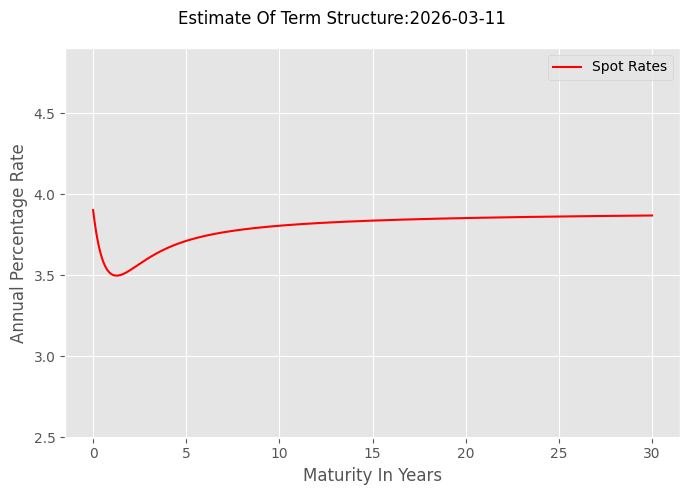

In [ ]:
(b_0,b_1,b_2,tau),std_error_coeff,std_error_short=nelson_siegel_estimates(df_td_estimates['Spot Rates'],td_maturity_years,settlement)
r_squared=np.round(calc_rsquared(b_0,b_1,b_2,tau,df_td_estimates['Spot Rates'],td_maturity_years),5)
display(md(f'## Nelson-Siegel Estimates: '+settlement.strftime('%Y-%m-%d ')))
x=pd.DataFrame({'Long Rate (Level)':(b_0,std_error_coeff[0]),'Slope':(b_1,std_error_coeff[1]),
              'Shape':(b_2,std_error_coeff[2]),'Maturity Scaling':(tau,std_error_coeff[3]),
              'Short Rate':(b_0-b_1,std_error_short)},index=['Estimate','Std. Error'])
display(md(f'### R-Squared: {r_squared}'))
display(x)
#Data to be plotted
spot_time=estimated_spot_rates(b_0,b_1,b_2,tau)
plot_data=[spot_time[0]*100]
#X axis time in years
xaxis=spot_time[1]
series=['Spot Rates']
ylabel='Annual Percentage Rate'
xlabel='Maturity In Years'
size=(7,5)
markers=['']
colors=['r']
y_lower=np.min(plot_data)-1
y_upper=np.max(plot_data)+1
ylim=[y_lower,y_upper]
title='Estimate Of Term Structure:'+settlement.strftime('%Y-%m-%d ')
one_y_axis(xaxis,plot_data,title,series,xlabel,ylabel,markers,size,ylim,
           colors=colors)

## <font color='green'>Application: Estimate Nelson and Siegel model for June 30$^{th}$ 2023</font>


 see [Chapter Nine Hints: Estimate Nelson and Siegel model for June 30 2023](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Hints.html#chapter-nine-hints), and check the [expected results here](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Results.html#chapter-nine-results).



## The Svensson extension
Two extra parmeters ($\beta_3\text{ and }\lambda$) are suggested to allow for additional curvature. The extended model is:

$\large r(t)=\beta_0+\beta_1\times\frac{1-e^{-t/\tau}}{t/\tau}+\beta_2\times(\frac{1-e^{-t/\tau}}{t/\tau}-e^{-t/\tau})+\beta_3\times(\frac{1-e^{-t/\lambda}}{t/\lambda}-e^{-t/\lambda})$

The extension is subject to a serious risk of overparameterization-the inability to find a solution or solution that changes dramatically with changes in the initial values or guesses.  Indeed, that is the case when the extended model is estimated with March 11$^{th}$ 2026 data. The Nelson-Siegel explains almost all the variation in the spot rates, adding two parameters adds complexity with little left to be explained.


## Calculating forward rates

The Nelson and Siegel model is parsimonious and enables the calculation of forward interest rates for any future date. As we have previously seen, forward rates are key to pricing financial instruments (including derivatives and fixed-income securities) and understanding market expectations regarding essential economic and financial metrics.


### Calculate zero prices at the respective dates
To calculate forward rates as the ratios of zero prices, the initial step involves estimating zero prices using the Nelson-Siegel model. The <font color='green'> calc_zero</font> function is utilized for this calculation, requiring the maturity date(s) and the estimated parameters of the Nelson-Siegel model as its inputs.


In [ ]:
def calc_zero(t,               #maturity dates
              b_0,b_1,b_2,tau):#estimted parameters of model

  # calculate the zero prices from forecasted spot rates
  # forecasted spot rates

  # make t numpy array so calculations of rates are vectorized
  t = np.asanyarray(t, dtype=float)

  # can't divided by zero & negative values set at 0.00001
  t=np.where(t <= 0, 0.0001,t)

  rate=b_0+b_1*(1-np.exp(-t/tau))/(t/tau)\
  +b_2*((1-np.exp(-t/tau))/(t/tau)-np.exp(-t/tau))

  # zero price
  return np.exp(-rate*t)

### Calculate the forward rates
The <font color='green'>calc_forward_rates</font> function requires the settlement dates, forward starting and ending dates, along with the estimated parameters for the Nelson-Siegel model. It first converts all input dates to Pandas timestamps, and the start and end dates are then converted to Pandas series representing years. A validation step uses the Pandas <font color='green'>any</font> method to confirm that all ending dates are greater than their corresponding starting dates. The calculated forward rates are returned as NumPy arrays.


In [ ]:
def calc_forward_rates(settlement,start_dates,end_dates,  #required dates
                       b_0,b_1,b_2,tau):                  #estimated parameters

  pd_settlement=pd.Timestamp(settlement)

  # convert start and end dates to years
  start_t=pd.Series((pd.to_datetime(start_dates)-pd_settlement).days)/365.25
  end_t=pd.Series((pd.to_datetime(end_dates)-pd_settlement).days)/365.25

  # validate dates
  if ((start_t-end_t)>=0).any():
    return 'start_dates must be < matching end_dates'

  # calculate the zero prices from forecasted spot rates
  # calculation is vectorized
  start_zero=calc_zero(start_t,b_0,b_1,b_2,tau)
  end_zero=calc_zero(end_t,b_0,b_1,b_2,tau)

  # annualized forward rate (end_t and start_t are in years)
  forward_rates=(np.log(start_zero/end_zero)/(end_t-start_t))
  return np.array(forward_rates)

## Calculate the forward rate for the second and fourth quarters of 2026 using March 11$^{th}$ 2026 estimates

In [ ]:
# set start and end dates as tuples to avoid values being changed
start_dates=(date(2026,4,1),date(2026,10,1))
end_dates=(date(2026,6,30),date(2026,12,31))

# calculate forward rates
forward_rates=calc_forward_rates(settlement,start_dates,end_dates,
                                 b_0,b_1,b_2,tau)

# create a DataFrame
df_forward=pd.DataFrame({'End Date':end_dates,'Forward Rate':forward_rates*100},
                        index=start_dates)

# rename the index
df_forward.index.name='Start Date'
display(df_forward)

,End Date,Forward Rate
Start Date,,
2026-04-01,2026-06-30,3.642442
2026-10-01,2026-12-31,3.407233


## <font color='green'>Application: Calculating Forward Rates with Nelson and Siegel Estimates</font>

 Using FEDInvest estimates for June 30$^{th}$ 2023.

1.   Calculate the forward rate for the fourth quarter of 2023.
2.   Calculate the forward rate for August 2023
3.   Calculate the forward rate for the year 2024



 see [Chapter Eight Hints: Calculating Forward Rates with Nelson and Siegel Estimates](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Hints.html#chapter-nine-hints), and check the [expected results here](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Results.html#chapter-nine-results)



## Calculating Par Yields with Nelson-Siegel model
In addition to forward rates, calculating par yields for arbitrary dates is a natural use case of Nelson and Siegel.

Recall from Chapter Five that par yields are derived from the formula:

>>$\text{Principal} = \sum _{t=1}^{T}\text{PV}(t)\times \text{Par Yield}\times\text{Principal}+ \text{PV}(T)\times\text{Principal}$

>>$\text{Par Yield}=\large\frac{1-PV(T)}{\sum _{t=1}^{T}PV(t)}$

<br>

The calculation assumes that the settlement date is the current date.  We can generalize for any settlement by adjusting the par value by the present value factor on the settlement date.

<br>

>>$\text{PV(settlement)}\times\text{Principal} = \sum _{t=1}^{T}\text{PV}(t)\times \text{Par Yield}\times\text{Principal}+ \text{PV}(T)\times\text{Principal}$

>>$\text{Par Yield}=\large\frac{\text{PV(settlement) - PV(T)}}{\sum _{t=1}^{T}\text{PV(t)}}$

<br>

The <font color='green'>calc_par_yield</font>  function adjusts for the time difference between the current date and the assumed settlement date. The actual payment dates are calculated with the functions <font color='green'>scheduled_pay_dates</font> and <font color='green'>adjust_bond_pay_dates</font> that are imported from the custom module.

The par yield is annualized by frequency of payments, although the actual payment intervals will vary (for quarterly frequency between ninety and ninety-two days). A more detailed solution is provided with our discussion of interest rate swaps.


In [ ]:
from basic_concepts_fixed_income import ()

In [ ]:
def calc_par_yield(start_date,end_date,freq=4):

  # make all dates pandas timestamps for vectorized calculations
  settlement_ts=pd.Timestamp(settlement)
  start_date_ts=pd.Timestamp(start_date)
  end_date_ts=pd.Timestamp(end_date)

  # validate dates
  if start_date_ts>=end_date_ts:
    return 'start_date must be < end date'

  # get the scheduled and actual payment dates
  scheduled_dates=scheduled_pay_dates(end_date_ts,start_date_ts,freq=freq)
  actual_dates=np.array([adjust_bond_pay_dates(scheduled)
   for scheduled in scheduled_dates])

  # convert dates to years
  t_start_date=(start_date_ts-settlement_ts).days/365.25
  t_pay_dates=(pd.to_datetime(actual_dates)-settlement_ts).days/365.25

  # vectorize zero price calculations
  pay_dates_zero=calc_zero(t_pay_dates,
                           b_0,b_1,b_2,tau)

  # single calculation for start_date
  start_date_zero=calc_zero(t_start_date,
                            b_0,b_1,b_2,tau)

  # par yield calculations
  par_yield=(start_date_zero-pay_dates_zero[-1])/np.sum(pay_dates_zero)*freq

  return par_yield

## Calculating Par Yields with Nelson-Siegel model for the period April 1$^{st}$ 2026 - March 31$^{st}$ 2031

In [ ]:
# Define the start and end dates
start_date = '2026-04-01'
end_date = '2031-03-31'

# display the results
par_yield=calc_par_yield(start_date,end_date)
display(md(f'#### Starting Date: {start_date}..Ending Date: {end_date}'))
display(md(f'#### Par Yield: {par_yield*100:.4f}%'))

#### Starting Date: 2026-04-01..Ending Date: 2031-03-31

#### Par Yield: 3.7197%

## <font color='green'>Exercise: Forecast the cost of fixed and floating rate debt</font>


Assume that your annualized borrowing rate is 100 basis points above the default-free rate.

1. What interest rates would you expect to be able to lock in on June 30$^{th}$ 2023 for 2024 if the rate resets at the beginning of every quarter.
2.  What interest rate would you expect to be able to lock in on March 16$^{th}$ 2026 for a loan that begins on June 1$^{st}$ 2026 and ends on May 31$^{st}$ 2036.


<br>

 see [Chapter Nine Hints: Forecast the cost of fixed and floating rate debt](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Hints.html#chapter-nine-hints), and check the [expected results here](https://patrickjhess.github.io/Hints-Results/Chapter_Nine_Results.html#chapter-nine-results).



## <font color='green'>Take a deeper dive with Gemini</font>


Some suggestions to get you started.

1.  How can I use the Nelson-Siegel model to evaluate an interest rate swap?
2.  Is the Nelson-Siegel model better than a linear approximation?
3.  Is the Nelson-Siegel mdoel better than a cubic spline approximation?

[Here is the link where you can copy and paste the questions](https://gemini.google.com)